In [1]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import ElasticNetCV
from load_data import get_dataset
from pipeline import get_preprocessor

In [2]:
X_train, X_test, y_train, y_test = get_dataset()

In [3]:
preprocessor = get_preprocessor()

In [4]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]

In [5]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ElasticNetCV(l1_ratio=l1_ratios, cv=5, n_jobs=-1, random_state=42))
])

In [6]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineer', ...), ('column_transformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...t 0x11ccd5590>
,"inverse_func inverse_func: callable, default=NoneThe callable to use fo

In [7]:
y_pred = pipe.predict(X_test)

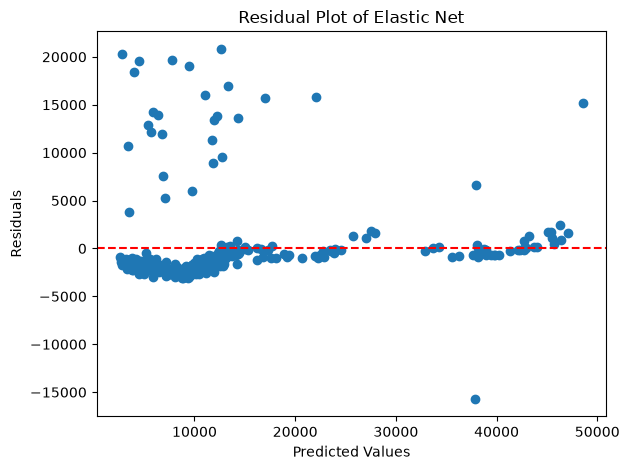

In [8]:
plt.title("Residual Plot of Elastic Net")
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.axhline(y=0, color='r', linestyle='--')
plt.tight_layout()
plt.savefig("images/residual_plot_of_elastic_net.png", dpi=1200)
plt.show()

In [9]:
print("Training")
print("R2 score", r2_score(y_train, pipe.predict(X_train)))
print("Mean absolute error", mean_absolute_error(y_train, pipe.predict(X_train)))
print("Mean squared error", mean_squared_error(y_train, pipe.predict(X_train)))
print("Root mean squared error", root_mean_squared_error(y_train, pipe.predict(X_train)))
print("\n")
print("Testing")
print("R2 score", r2_score(y_test, y_pred))
print("Mean absolute error", mean_absolute_error(y_test, y_pred))
print("Mean squared error", mean_squared_error(y_test, y_pred))
print("Root mean squared error", root_mean_squared_error(y_test, y_pred))

Training
R2 score 0.8638715407298225
Mean absolute error 2469.4246162024633
Mean squared error 19750931.76548672
Root mean squared error 4444.202039228946


Testing
R2 score 0.8679401001077445
Mean absolute error 2485.620438605907
Mean squared error 19926668.804013148
Root mean squared error 4463.929749000666
